<h1 style="
text-align: center;
font-size: 42px;
font-weight: bold;
color: #00E5FF;
text-shadow: 0px 0px 10px #00E5FF80;
">
PureAir Predictor 🌿
</h1>


#### Objective:
##### To perform comprehensive air quality analysis and create a predictive machine learning model that estimates pollutant concentration values using features such as indicator type, time period, geographical information, and seasonal attributes.
##### The project aims to uncover pollution trends, identify key contributing factors, and generate accurate predictions to support environmental planning and improve air quality monitoring systems.

In [2]:
# Importing all required libraries
import pandas as pd    # For data loading and manipulation
import numpy as np     # For numerical operations
import seaborn as sns  # For visualizations
import matplotlib.pyplot as plt   # For plots
from sklearn.model_selection import train_test_split     # Split data into train and test sets
from sklearn.linear_model import LinearRegression        # Linear Regression model
from sklearn.ensemble import RandomForestRegressor       # Random Forest Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

In [3]:
sns.set_style("darkgrid")

custom_palette = [
    "#00E5FF",  # Neon Cyan
    "#B388FF",  # Light Purple
    "#7C4DFF",  # Deep Violet
    "#18FFFF",  # Bright Teal
    "#FF80AB",  # Neon Pink
    "#80D8FF"   # Soft Sky Blue
]

sns.set_palette(custom_palette)

plt.rcParams["figure.facecolor"] = "#121212"
plt.rcParams["axes.facecolor"] = "#1D1D1D"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.labelcolor"] = "#FFFFFF"
plt.rcParams["xtick.color"] = "#FFFFFF"
plt.rcParams["ytick.color"] = "#FFFFFF"
plt.rcParams["text.color"] = "#FFFFFF"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlepad"] = 14


In [4]:
#  Loading the Air Quality dataset
df=pd.read_csv("Air_Quality.csv")

In [5]:
# View first few rows to understand structure
df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN


<h3 style="color:#4DC3FF; font-weight:bold;">
Step 1: Exploratory Data Analysis (EDA)
</h3>

<h3 style="color:#66CC66; font-weight:bold;">
Step 2: Preparing Data for Prediction Model
</h3>


In [6]:
# Shape of the dataset
df.shape

(18862, 12)

In [7]:
# Data types and non-null info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [8]:
# Quick stats for numerical columns
df.describe()

,Unique ID,Indicator ID,Geo Join ID,Data Value,Message
count,18862.000000,18862.000000,1.886200e+04,18862.000000,0.0
mean,452004.167533,431.817888,5.983262e+05,21.051580,NaN
std,262910.731230,113.946565,7.819721e+06,23.564920,NaN
min,130355.000000,365.000000,1.000000e+00,0.000000,NaN
25%,176073.250000,365.000000,2.020000e+02,8.742004,NaN
50%,412490.500000,375.000000,3.030000e+02,14.790000,NaN
75%,669588.750000,386.000000,4.040000e+02,26.267500,NaN
max,878254.000000,661.000000,1.051061e+08,424.700000,NaN


In [9]:
# See now I am dropping the columns which is not useful in predicting. As per above data
# 'Message' is empty, 'Unique ID' is just an identifier (no predictive power)
cols_to_drop = ["Message", "Unique ID"]
df = df.drop(columns=cols_to_drop, errors="ignore")

In [10]:
df.columns.tolist()  # Checking what I have dropped is present in my dataset or not

['Indicator ID',
 'Name',
 'Measure',
 'Measure Info',
 'Geo Type Name',
 'Geo Join ID',
 'Geo Place Name',
 'Time Period',
 'Start_Date',
 'Data Value']

In [11]:
# Converting Start_Date from string to datetime
df["Start_Date"] = pd.to_datetime(df["Start_Date"], errors="coerce")

In [12]:
# Checking if any dates failed to convert
df["Start_Date"].isna().sum()

np.int64(0)

In [13]:
# Create new time-based features (Year, Month, Day)
df["Year"] = df["Start_Date"].dt.year
df["Month"] = df["Start_Date"].dt.month
df["Day"] = df["Start_Date"].dt.day

In [14]:
df.head() # again checking ,Is it converted or not?

,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Year,Month,Day
0,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,2014-12-01,23.97,2014,12,1
1,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,2014-12-01,27.42,2014,12,1
2,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,2017-01-01,12.55,2017,1,1
3,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,2015-12-01,22.63,2015,12,1
4,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,2016-06-01,14.00,2016,6,1


In [15]:
# Create Season feature from Month
def get_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    elif m in [9, 10, 11]:
        return "Autumn"
    else:
        return "Unknown"

In [16]:
df["Season"] = df["Month"].apply(get_season)

In [17]:
df.head() # Checking if Season Column is converted or not

,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Year,Month,Day,Season
0,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,2014-12-01,23.97,2014,12,1,Winter
1,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,2014-12-01,27.42,2014,12,1,Winter
2,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,2017-01-01,12.55,2017,1,1,Winter
3,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,2015-12-01,22.63,2015,12,1,Winter
4,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,2016-06-01,14.00,2016,6,1,Summer


In [18]:
# Remove duplicate rows, if Duplicates before comes '0' then we do not need to apply unnecessarily drop 
print("Duplicates before:")
df.duplicated().sum()

Duplicates before:


np.int64(0)

In [19]:
# Check missing values after cleaning
df.isna().sum()

Indicator ID      0
Name              0
Measure           0
Measure Info      0
Geo Type Name     0
Geo Join ID       0
Geo Place Name    0
Time Period       0
Start_Date        0
Data Value        0
Year              0
Month             0
Day               0
Season            0
dtype: int64

In [20]:
# If 'Data Value' (target) has missing values, drop those rows
df = df.dropna(subset=["Data Value"])

In [21]:
print("Shape after dropping rows with missing target:")
df.shape

Shape after dropping rows with missing target:


(18862, 14)

<h2 style="color:#FFFFFF; font-weight:bold; text-align:left;
text-shadow:0px 0px 10px #00E5FF;">
Preparing Data for Prediction Model
</h2>


In [22]:
# Defining target (y) and feature set (X)
# So here is my Target variable
y = df["Data Value"]

In [23]:
# Features used to predict air quality
feature_cols = ["Indicator ID","Geo Join ID","Year","Month","Name","Measure","Measure Info","Geo Type Name","Geo Place Name","Time Period","Season"]

In [24]:
X = df[feature_cols]

In [25]:
X.head() 

,Indicator ID,Geo Join ID,Year,Month,Name,Measure,Measure Info,Geo Type Name,Geo Place Name,Time Period,Season
0,375,407,2014,12,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Winter 2014-15,Winter
1,375,107,2014,12,Nitrogen dioxide (NO2),Mean,ppb,CD,Upper West Side (CD7),Winter 2014-15,Winter
2,375,414,2017,1,Nitrogen dioxide (NO2),Mean,ppb,CD,Rockaway and Broad Channel (CD14),Annual Average 2017,Winter
3,375,407,2015,12,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Winter 2015-16,Winter
4,375,407,2016,6,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Summer 2016,Summer


In [26]:
# Converting categorical variables into numeric using OneHotEncoding
X = pd.get_dummies(X, drop_first=True)

In [27]:
print("Shape after encoding:")
X.shape

Shape after encoding:


(18862, 209)

In [28]:
# Train-test split (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
print("Training set size:")
X_train.shape

Training set size:


(15089, 209)

In [30]:
print("Testing set size:")
X_test.shape

Testing set size:


(3773, 209)

<h2 style="color:#FFFFFF; font-weight:bold; text-align:left;
text-shadow:0px 0px 10px #00E5FF;">
Building Prediction Models
</h2>


#### We will build two models:

##### 1️ Linear Regression (simple baseline)
##### 2️ Random Forest Regressor (better accuracy)

In [31]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

In [33]:
# Train Random Forest Regressor (strong model)
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=250,    # number of trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

In [34]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test) # Predict on test data

### Model Evaluation

In [35]:
# Function to evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [36]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("MAE  :", round(mae, 3))
    print("MSE  :", round(mse, 3))
    print("RMSE :", round(rmse, 3))
    print("R² Score:", round(r2, 3))
    print()

In [37]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

--- Linear Regression ---
MAE  : 6.831
MSE  : 252.619
RMSE : 15.894
R² Score: 0.606

--- Random Forest Regressor ---
MAE  : 1.682
MSE  : 39.173
RMSE : 6.259
R² Score: 0.939



In [38]:
def air_quality_category(value):
    if value <= 12:
        return "Good 😊 (Safe to inhale)"
    elif value <= 35:
        return "Moderate 🙂 (Acceptable air quality)"
    elif value <= 55:
        return "Unhealthy for Sensitive Groups 😷"
    elif value <= 150:
        return "Unhealthy ⚠️ (Not safe to inhale)"
    elif value <= 250:
        return "Very Unhealthy 🚫 (Dangerous)"
    else:
        return "Hazardous ☠️ (Severe health risk)"

### Plot Actual vs Predicted (For Random Forest)

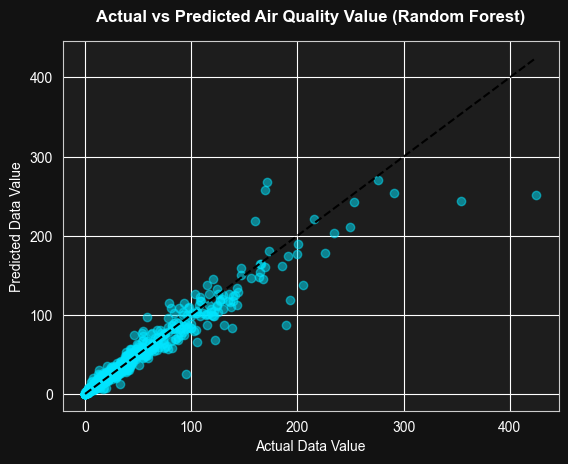

In [39]:
#  Visual comparison of Actual vs Predicted values
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.title("Actual vs Predicted Air Quality Value (Random Forest)")
plt.xlabel("Actual Data Value")
plt.ylabel("Predicted Data Value")
# adding the reference line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')
plt.show()

In [40]:
# Feature importance (which inputs affect prediction most)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)

In [41]:
# Top 15 most important features
top_features = feat_imp.sort_values(ascending=False).head(15)

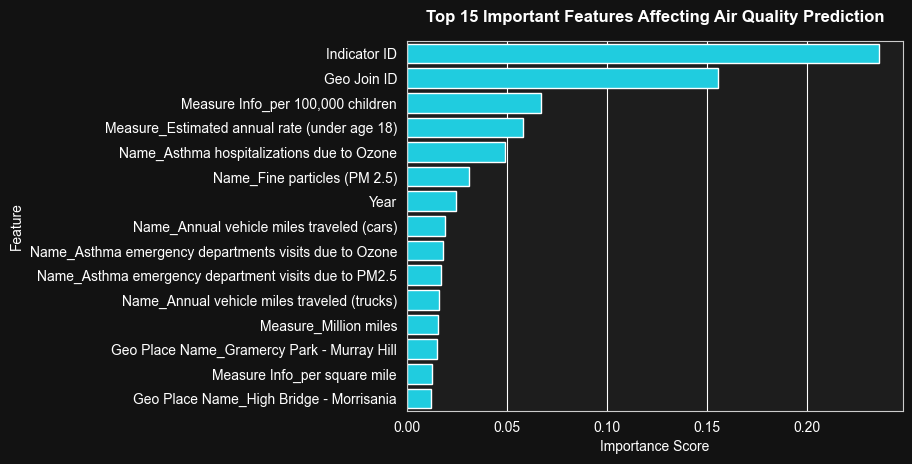

In [42]:
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Important Features Affecting Air Quality Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [43]:
#Test prediction and category conversion

sample_pred = y_pred_rf[55]

print("Predicted Data Value:", round(sample_pred, 2))
print("Air Quality Category:", air_quality_category(sample_pred))

Predicted Data Value: 27.56
Air Quality Category: Moderate 🙂 (Acceptable air quality)


In [44]:
sample_pred = y_pred_rf[6]
category = air_quality_category(sample_pred)

from IPython.display import HTML, display

display(HTML(f"""
<div style="
    background-color:#1E1E1E;
    padding:15px;
    border-radius:10px;
    border-left:8px solid #00E5FF;
    color:white;
    font-size:18px;
    font-weight:bold;
">
    <p>🔍 <span style='color:#00E5FF;'>Predicted Air Quality Value:</span> {round(sample_pred, 2)}</p>
    <p>💡 <span style='color:#00E5FF;'>Air Quality Category:</span> {category}</p>
</div>
"""))
